<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/Regression_polynomiale_3_5_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [11]:
X,Y = make_regression(n_samples=100, n_features=3, noise= 10, random_state=42)
X[:,1]=X[:,0]*X[:,0]
X[:,2]=X[:,0]*X[:,0]*X[:,0]

In [12]:
X.shape, Y.shape

((100, 3), (100,))

In [13]:
Y=Y.reshape(100,1)
Y.shape

(100, 1)

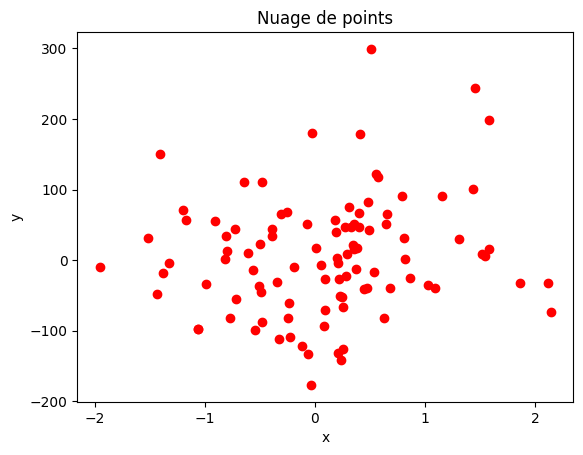

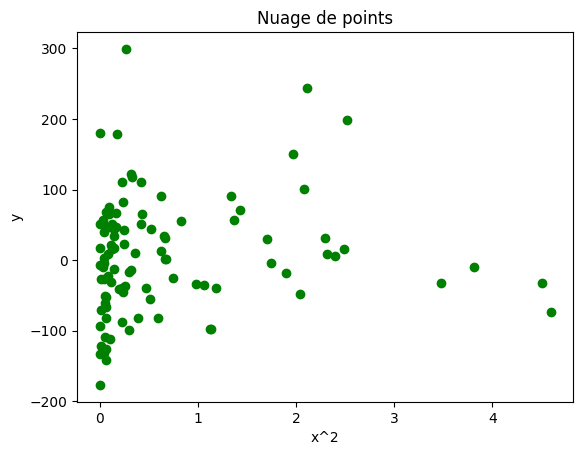

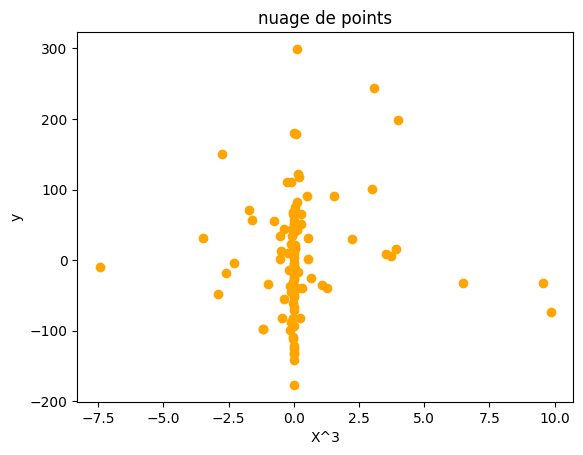

In [14]:
plt.scatter(X[:, 0] , Y , c='red')
plt.title('Nuage de points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

plt.scatter(X[:,1] , Y , c='green')
plt.title('Nuage de points')
plt.xlabel('x^2')
plt.ylabel('y')
plt.show()

plt.scatter(X[:,2] , Y , c='orange')
plt.title('nuage de points')
plt.xlabel('X^3')
plt.ylabel('y')
plt.show()

In [15]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=40,shuffle=True)

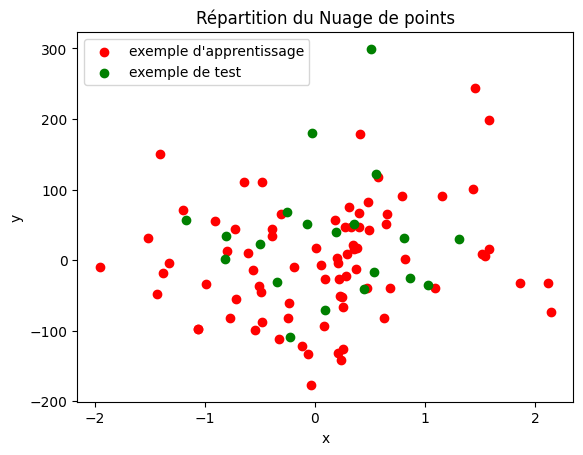

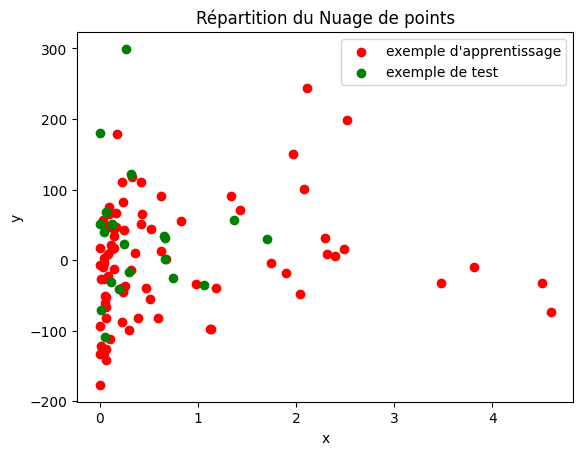

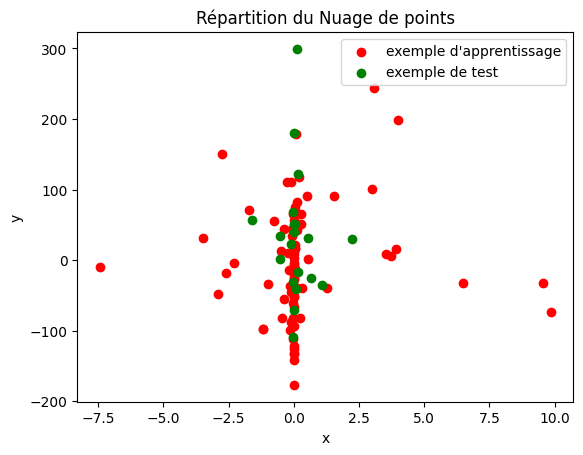

In [16]:
plt.scatter(X_train[:,0],Y_train, c='red', label="exemple d'apprentissage")
plt.scatter(X_test[:,0],Y_test, c='green', label="exemple de test")
plt.legend()
plt.title('Répartition du Nuage de points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.scatter(X_train[:,1],Y_train, c='red', label="exemple d'apprentissage")
plt.scatter(X_test[:,1],Y_test, c='green', label="exemple de test")
plt.legend()
plt.title('Répartition du Nuage de points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
plt.scatter(X_train[:,2],Y_train, c='red', label="exemple d'apprentissage")
plt.scatter(X_test[:,2],Y_test, c='green', label="exemple de test")
plt.legend()
plt.title('Répartition du Nuage de points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [63]:
def transformation_variables_explicatives(X):
  vect_un=np.ones((len(X),1))
  return np.hstack((X,vect_un))

In [64]:
def model_lineaire_scalaire(X,Beta):
  return X*Beta[0]+Beta[1]

In [65]:
def model_lineaire_matricielle(X,Beta):
  X=transformation_variables_explicatives(X)
  return X.dot(Beta)  #X.dot(beta)

In [66]:
def fonction_Cout_Notation_Scalaire(Y,X,Beta):
  return np.sum((Y-model_lineaire_scalaire(X,Beta))**2)/len(Y)

In [80]:
  def fonction_Cout_Notation_Matricielle(Y,X,Beta):
    X=transformation_variables_explicatives(X)
    term1=X @ Beta-Y
    n=len(Y)
    return 1/n*term1.T@term1

#Méthode des moindres carrés pour estimer les paramètres du modèle(Vecteur Beta)

In [67]:
def moindres_carres_matricielle(X,Y):
  X= transformation_varibales_explicatives(X)
  Beta_estimer=np.linalg.inv(X.T@X)@X.T@Y
  return Beta_estimer

In [68]:
beta_estimer=moindres_carres_matricielle(X_train,Y_train)
beta_estimer

array([[ 53.02945357],
       [ 18.49830482],
       [-18.93642941],
       [-13.6523466 ]])

In [69]:
x_min=np.min(X_train)
x_max=np.max(X_train)
points=np.linspace(x_min,x_max,10)
points=points.reshape(-1,1)
points.shape

(10, 1)

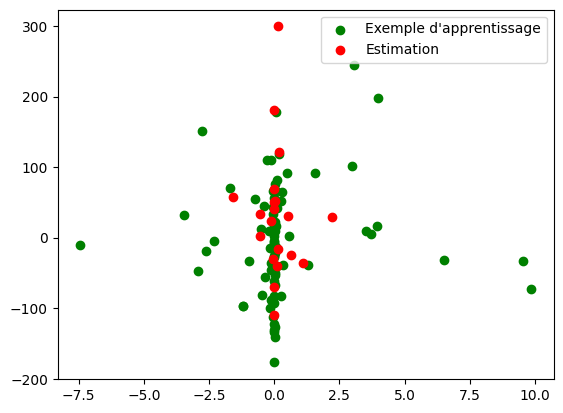

In [70]:
y_pred=model_lineaire_matricielle(X_test,beta_estimer)
plt.scatter(X_train[:,2],Y_train,c='green',label="Exemple d'apprentissage")
plt.scatter(X_test[:,2],Y_test,c='red',label="Estimation")
plt.legend()
plt.show()

**Regression linéaire avec l'api SKlearn**

In [71]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [72]:
model.coef_,model.intercept_

(array([[ 53.02945357,  18.49830482, -18.93642941]]), array([-13.6523466]))

# Implementation de la méthode de descente de gradienta

In [73]:
def gradient(X,Beta,Y):
  n=len(X)
  X=transformation_variables_explicatives(X)
  return (2/n)*X.T@(X@Beta-Y)


def descentGradient(X,Beta,Y,alpha=0.01,n_iteration=2000):
  for i in range(n_iteration):
    Beta=Beta-alpha*gradient(X,Beta,Y)

  return Beta


def history_descentGradient(X,Beta,Y,alpha=0.01,n_iteration=2000):
  errors=[]
  for i in range(n_iteration):
    Beta=Beta-alpha*gradient(X,Beta,Y)
    err=fonction_Cout_Notation_Matricielle(Y,X,Beta)[0][0]
    print(err)
    errors.append(err)
  return Beta,errors

In [82]:
Beta=np.random.randn(2,1)
beta_estimer_DG,erreurs=history_descentGradient(X_train,Beta,Y_train)
print(beta_estimer_DG)

#(array([[52.92721084]]), array([-0.31349312]))

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 4)

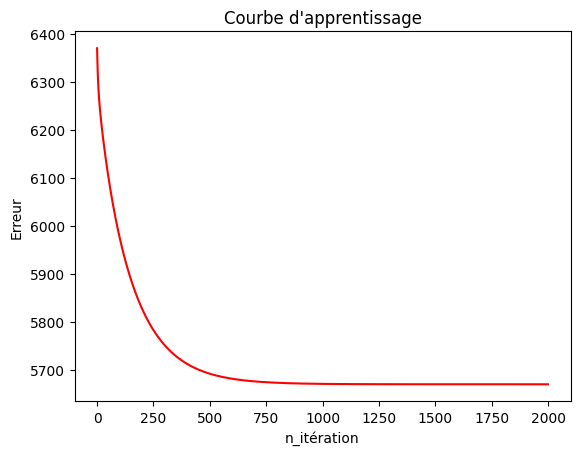

In [83]:
plt.plot(erreurs,c='r')
plt.xlabel("n_itération")
plt.ylabel("Erreur")
plt.title("Courbe d'apprentissage")
plt.show()


In [84]:
print(fonction_Cout_Notation_Matricielle(Y_train,X_train,beta_estimer_DG))

[[5669.53893567]]


In [85]:
def coefficient_detemination(y_true,y_pred):
  y_mean=np.mean(y_true)
  sct=np.sum((y_true-y_mean)**2)
  scr=np.sum((y_true-y_pred)**2)
  return 1-(scr/sct)

In [86]:
y_true=Y_test
y_pred=model_lineaire_matricielle(X_test,beta_estimer_DG)
coefficient_detemination(y_true,y_pred)*100

np.float64(-19.940507743915003)